### Telco Customer Churn

#### Contexto
A perda acelerada de clientes da base ativa, gerando queda direta na receita recorrente da operadora. A diretoria necessita identificar clientes em risco com antecedência para permitir ações proativas e direcionadas da equipe de retenção.

#### Dicionário de Dados
**CustomerID**: ID único que identifica cada cliente.

**Count**: Valor usado em relatórios e painéis para somar o número de clientes em um conjunto filtrado.

**Country**: O país de residência principal do cliente.

**State**: O estado de residência principal do cliente.

**City**: A cidade de residência principal do cliente.

**Zip Code**: O código postal da residência principal do cliente.

**Lat Long**: Latitude e longitude combinadas da residência principal do cliente.

**Latitude**: A latitude da residência principal do cliente.

**Longitude**: A longitude da residênca principal do cliente.

**Gender**: O gênero do cliente: Male, Female

**Senior Citizen**: Indica se o cliente tem mais de 65 anos: Yes, No

**Partner**: Indica se o cliente tem um(a) parceiro(a): Yes, No

**Dependents**: Indica se o cliente vive com dependentes: Yes, No. Dependentes podem ser filhos, pais, avós, etc.

**Tenure Months**: Indica a quantidade total de meses que o cliente é um cliente até a data.

**Phone Service**: Indica se o cliente assina um serviço de linha telefônica fixa com a companhia: Yes, No

**Multiple Lines**: Indica se o cliente assina múltiplas linhas telefônicas com a companhia: Yes, No

**Internet Service**: Indica se o cliente assina um serviço de Internet com a companhia: No, DSL, Fiber Optic, Cable.

**Online Security**: Indica se o cliente assina um serviço adicional de segurança online fornecido pela companhia: Yes, No

**Online Backup**: Indica se o cliente assina um serviço adicional de backup online fornecido pela companhia: Yes, No

**Device Protection**: Indica se o cliente assina um plano adicional de proteção para dispositivos fornecido pela companhia para o seu equipamento de Internet: Yes, No

**Tech Support**: Indica se o cliente assina um plano adicional de suporte técnico da companhia com tempo de espera reduzido: Yes, No

**Streaming TV**: Indica se o cliente usa seu serviço de Internet para o stream de programação de televisão de um fornecedor terceiro: Yes, No. A companhia não cobra taxas adicionais por este serviço.

**Streaming Movies**: Indica se o cliente usa seu serviço de Internet para o stream de filmes de um fornecedor terceiro: Yes, No. A companhia não cobra taxas adicionais por este serviço.

**Contract**: Indica o tipo de contrato atual do cliente: Month-to-Month, One Year, Two Year.

**Paperless Billing**: Indica se o cliente escolheu cobrança virtual: Yes, No

**Payment Method**: Indica como o cliente paga sua conta: Bank Withdrawal, Credit Card, Mailed Check

**Monthly Charge**: Indica o valor mensal total cobrado do cliente pelos serviços fornecidos pela companhia.

**Total Charges**: Indica o valor total cobrado do cliente, calculado até a data.

**Churn Label**: Yes = o cliente deixou a companhia neste trimestre. No = o cliente permaneceu com a companhia. Diretamente relacionado ao Churn Value.

**Churn Value**: 1 = o cliente deixou a companhia neste trimestre. 0 = o cliente permaneceu com a companhia. Diretamente relacionado ao Churn Label.

**Churn Score**: Um valor entre 0-100 calculado usando a ferramenta preditiva IBM SPSS Modeler. O modelo incorpora múltiplos fatores conhecidos por causar churn. Quanto maior o valor, maior a chance do cliente deixar a companhia.

**CLTV**: Customer Lifetime Value. O CLTV predito é calculado usando fórmulas corporataivas e dados existentes. Quanto maior o valor, mais valioso é o cliente. Clientes valiosos devem ser monitorados para o churn.

**Churn Reason**: O motivo específico que levou o cliente a deixar a companhia.

---

#### 1. Configuração do Ambiente

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

#### 2. Carregamento e Entendimento Inicial dos Dados

In [3]:
# Carrega o conjunto de dados e exibe os 5 primeiros registros
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

print(f"Shape dos dados: {df.shape}")
print("\nPrimeiras linhas do conjunto:")
df.head()

Shape dos dados: (7043, 33)

Primeiras linhas do conjunto:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df.describe(include="all")

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
count,7043,7043.0,7043,7043,7043,7043.000000,7043,7043.000000,7043.000000,7043,7043,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.0,7043,7043.000000,7043.000000,7043.000000,1869
unique,7043,NaN,1,1,1129,NaN,1652,NaN,NaN,2,2,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531.0,2,NaN,NaN,NaN,20
top,3668-QPYBK,NaN,United States,California,Los Angeles,NaN,"33.964131, -118.272783",NaN,NaN,Male,No,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No,NaN,NaN,NaN,Attitude of support person
freq,1,NaN,7043,7043,305,NaN,5,NaN,NaN,3555,5901,3641,5416,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11.0,5174,NaN,NaN,NaN,192
mean,NaN,1.0,NaN,NaN,NaN,93521.964646,NaN,36.282441,-119.798880,NaN,NaN,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN,0.265370,58.699418,4400.295755,NaN
std,NaN,0.0,NaN,NaN,NaN,1865.794555,NaN,2.455723,2.157889,NaN,NaN,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN,0.441561,21.525131,1183.057152,NaN
min,NaN,1.0,NaN,NaN,NaN,90001.000000,NaN,32.555828,-124.301372,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN,0.000000,5.000000,2003.000000,NaN
25%,NaN,1.0,NaN,NaN,NaN,92102.000000,NaN,34.030915,-121.815412,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN,0.000000,40.000000,3469.000000,NaN
50%,NaN,1.0,NaN,NaN,NaN,93552.000000,NaN,36.391777,-119.730885,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN,0.000000,61.000000,4527.000000,NaN
75%,NaN,1.0,NaN,NaN,NaN,95351.000000,NaN,38.224869,-118.043237,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN,1.000000,75.000000,5380.500000,NaN


Nesta primeira interação com os dados, notamos que algumas colunas não possuem variância, isto é, possuem um único valor (`Count`, `Country`, `State`).
Outras, são colunas utilizadas exclusivamente como identificadores (`CustomerID`) ou calculadas a posteriori (`Churn Label`, `Churn Score` e `Churn Reason`). Todas elas colunas podem ser removidas sem prejuízo à análise.

In [24]:
df = df.drop(
    columns=[
        "CustomerID",
        "Count",
        "Country",
        "State",
        "Churn Label",
        "Churn Score",
        "Churn Reason",
    ]
)

Além disso, notamos que a coluna `Total Charges`, apesar de descrita como uma coluna numérica, apresenta o tipo `object`. O que indica a necessidade de um pré-processamento para conversão ao tipo correto. Vamos analisar esta coluna.

In [ ]:
# O comando coerce força a conversão ao tipo numérico, atribuindo NaN para os valores que não podem ser convertidos
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df[df["Total Charges"].isnull()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


Identificamos que 11 registros apresentam o valor de `Total Charges` nulo. Isso se deve ao fato de serem clientes novos, com 0 meses de relacionamento com a companhia. Dessa forma, atribuímos o valor de 0 à `Total Charges` para preservar os registros de novos clientes.

In [18]:
df["Total Charges"] = df["Total Charges"].fillna(0)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   str    
 1   Zip Code           7043 non-null   int64  
 2   Lat Long           7043 non-null   str    
 3   Latitude           7043 non-null   float64
 4   Longitude          7043 non-null   float64
 5   Gender             7043 non-null   str    
 6   Senior Citizen     7043 non-null   str    
 7   Partner            7043 non-null   str    
 8   Dependents         7043 non-null   str    
 9   Tenure Months      7043 non-null   int64  
 10  Phone Service      7043 non-null   str    
 11  Multiple Lines     7043 non-null   str    
 12  Internet Service   7043 non-null   str    
 13  Online Security    7043 non-null   str    
 14  Online Backup      7043 non-null   str    
 15  Device Protection  7043 non-null   str    
 16  Tech Support       7043 non-null   

#### 3. Análise Exploratória de Dados (EDA)

##### 3.1. Análise de Valores Faltantes

In [26]:
missing_values = pd.DataFrame(
    {
        "Coluna": df.columns,
        "Missing_Count": df.isnull().sum(),
        "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2),
    }
)

missing_values = missing_values[missing_values["Missing_Count"].gt(0)].sort_values(
    by="Missing_Percentage", ascending=False
)

missing_values

,Coluna,Missing_Count,Missing_Percentage


Como observado no início da análise, apenas a coluna `Churn Reason` (já removida) possuía valores faltantes.

De qualquer maneira, abaixo construiremos um gráfico para visualização da proporção de valores faltantes por coluna, para futura referência.

In [27]:
if len(missing_values) > 0:
    print(missing_values)

    plt.figure(figsize=(10, 3))
    plt.barh(
        missing_values["Coluna"], missing_values["Missing_Percentage"], color="coral"
    )
    plt.xlabel("Porcentagem de Missing Values (%)")
    plt.title("Distribuição de Missing Values por Coluna")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum valor faltante detectado!")

Nenhum valor faltante detectado!


##### 3.2. Análise da Variável Alvo

In [28]:
# Renomear variável `Churn Value` para `target`
df.rename(columns={"Churn Value": "target"}, inplace=True)

Uma análise dos valores únicos da variável alvo nos mostra que ela já está binarizada e é do tipo inteira (conforme `df.info()`).

In [29]:
df["target"].unique()

array([1, 0])

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:
Não churn (0): 73.46%
Churn (1): 26.54%


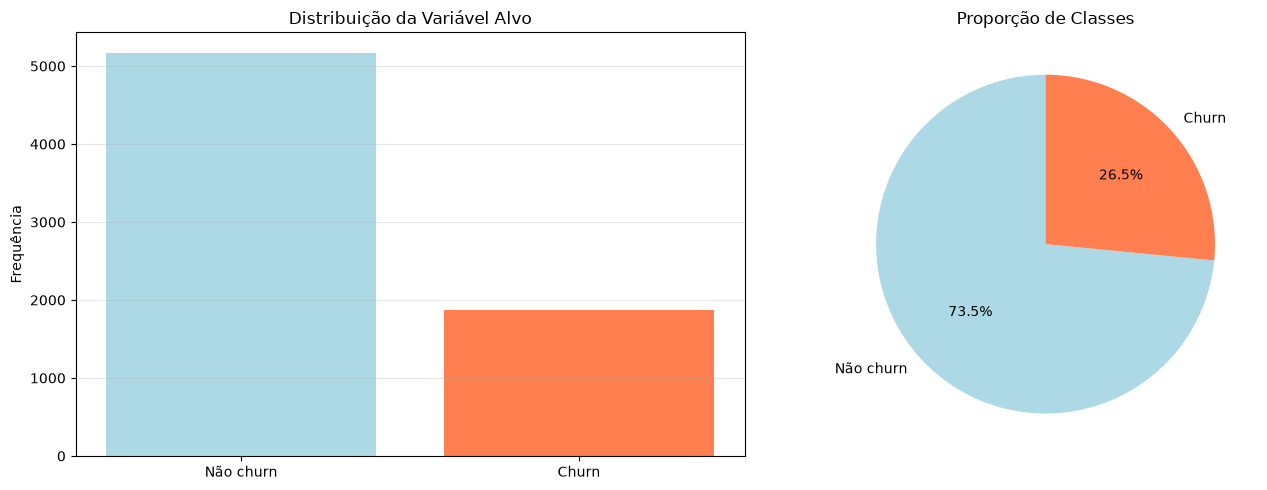


Razão de balanceamento: 0.36
Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [30]:
target_counts = df["target"].value_counts()
target_percentages = df["target"].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)

print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Churn" if idx == 1 else "Não churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Gráfico de barras
axes[0].bar(["Não churn", "Churn"], target_counts.values, color=["lightblue", "coral"])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Alvo')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=["Não churn", "Churn"], autopct="%1.1f%%", colors=["lightblue", "coral"], startangle=90)
axes[1].set_title('Proporção de Classes')
plt.tight_layout()
plt.show()

# Verifição de desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRazão de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("Dataset razoavelmente balanceado.")